# Credit Risk Prediction — Modeling

Five classifiers are trained on the preprocessed data and compared on the held-out test set.

| # | Model | Class-imbalance strategy |
|---|-------|--------------------------|
| 1 | Logistic Regression | `class_weight='balanced'` |
| 2 | Linear SVM + Platt calibration | `class_weight='balanced'` |
| 3 | Random Forest | `class_weight='balanced'` |
| 4 | XGBoost | `scale_pos_weight` |
| 5 | LightGBM | `class_weight='balanced'` |

Primary metric: **ROC-AUC**. Secondary: macro F1, recall on the default class (1).

> All models are saved to `models/` for use in the evaluation notebook.

In [1]:
import os, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score,
    classification_report, confusion_matrix, roc_curve
)
from sklearn.model_selection import StratifiedKFold, cross_val_score

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)

MODELS_DIR = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

## 1. Load Processed Data

In [2]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f'X_train : {X_train.shape}  |  default rate: {y_train.mean():.1%}')
print(f'X_test  : {X_test.shape}   |  default rate: {y_test.mean():.1%}')
print(f'Features: {X_train.shape[1]}')

X_train : (26059, 32)  |  default rate: 21.8%
X_test  : (6515, 32)   |  default rate: 21.8%
Features: 32


## 2. Training Utilities

Helper functions used by every model:
- `evaluate_and_store` — computes all metrics, prints a report, and stores results
- `plot_confusion` — normalized confusion matrix heatmap
- `cv_auc` — 5-fold stratified cross-validation ROC-AUC on the training set

In [3]:
results = {}   # metric scores per model
probs   = {}   # test-set predicted probabilities for ROC plotting

def evaluate_and_store(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]

    auc  = roc_auc_score(y_te, y_prob)
    f1   = f1_score(y_te, y_pred, average='macro')
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, pos_label=1, zero_division=0)
    rec  = recall_score(y_te, y_pred, pos_label=1)

    print(f"\n{'='*55}")
    print(f'  {name}')
    print(f"{'='*55}")
    print(f'  ROC-AUC    : {auc:.4f}')
    print(f'  F1 (macro) : {f1:.4f}')
    print(f'  Accuracy   : {acc:.4f}')
    print(f'  Precision  : {prec:.4f}  (default class)')
    print(f'  Recall     : {rec:.4f}  (default class)')
    print(classification_report(y_te, y_pred,
                                target_names=['No Default', 'Default']))

    results[name] = {
        'ROC-AUC'     : round(auc,  4),
        'F1-macro'    : round(f1,   4),
        'Accuracy'    : round(acc,  4),
        'Precision(1)': round(prec, 4),
        'Recall(1)'   : round(rec,  4),
    }
    probs[name] = y_prob


def plot_confusion(name, model, X_te, y_te):
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_te, y_pred, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Blues',
                xticklabels=['No Default', 'Default'],
                yticklabels=['No Default', 'Default'])
    plt.title(f'Confusion Matrix — {name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()


def cv_auc(model, X, y, n_splits=5):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    scores = cross_val_score(model, X, y, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
    print(f'  CV ROC-AUC ({n_splits}-fold): {scores.mean():.4f} +/- {scores.std():.4f}')
    return scores

## 3. Logistic Regression

A strong, interpretable linear baseline. L2 regularisation (`C=1.0`) and `class_weight='balanced'` to compensate for the 78/22 class split. The `lbfgs` solver handles multi-dimensional problems efficiently.

Training Logistic Regression...


  Training time: 0.2s

  CV ROC-AUC (5-fold): 0.8695 +/- 0.0040

  Logistic Regression
  ROC-AUC    : 0.8595
  F1 (macro) : 0.7340
  Accuracy   : 0.7897
  Precision  : 0.5121  (default class)
  Recall     : 0.7614  (default class)
              precision    recall  f1-score   support

  No Default       0.92      0.80      0.86      5094
     Default       0.51      0.76      0.61      1421

    accuracy                           0.79      6515
   macro avg       0.72      0.78      0.73      6515
weighted avg       0.83      0.79      0.80      6515



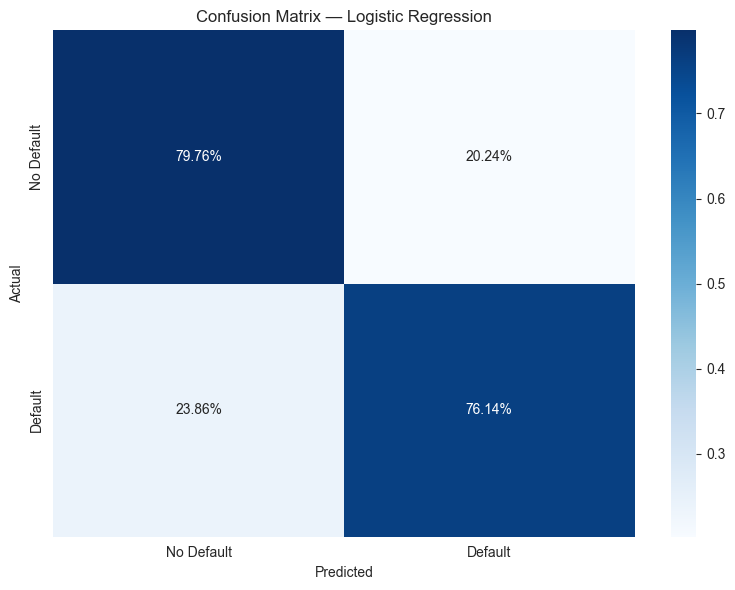

  Saved: models/logistic_regression.pkl


In [4]:
print('Training Logistic Regression...')
t0 = time.time()

lr = LogisticRegression(
    C=1.0,
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    random_state=42
)
lr.fit(X_train, y_train)
print(f'  Training time: {time.time() - t0:.1f}s')

cv_auc(lr, X_train, y_train)
evaluate_and_store('Logistic Regression', lr, X_test, y_test)
plot_confusion('Logistic Regression', lr, X_test, y_test)

joblib.dump(lr, f'{MODELS_DIR}/logistic_regression.pkl')
print('  Saved: models/logistic_regression.pkl')

## 4. Support Vector Machine (Linear)

`LinearSVC` is significantly faster than kernel SVM on large datasets. Platt calibration (`CalibratedClassifierCV`) is applied to produce probability estimates needed for ROC-AUC computation.

Training Linear SVM + Platt calibration...


  Training time: 1.2s

  SVM (Linear)
  ROC-AUC    : 0.8595
  F1 (macro) : 0.7505
  Accuracy   : 0.8507
  Precision  : 0.7319  (default class)
  Recall     : 0.4975  (default class)
              precision    recall  f1-score   support

  No Default       0.87      0.95      0.91      5094
     Default       0.73      0.50      0.59      1421

    accuracy                           0.85      6515
   macro avg       0.80      0.72      0.75      6515
weighted avg       0.84      0.85      0.84      6515



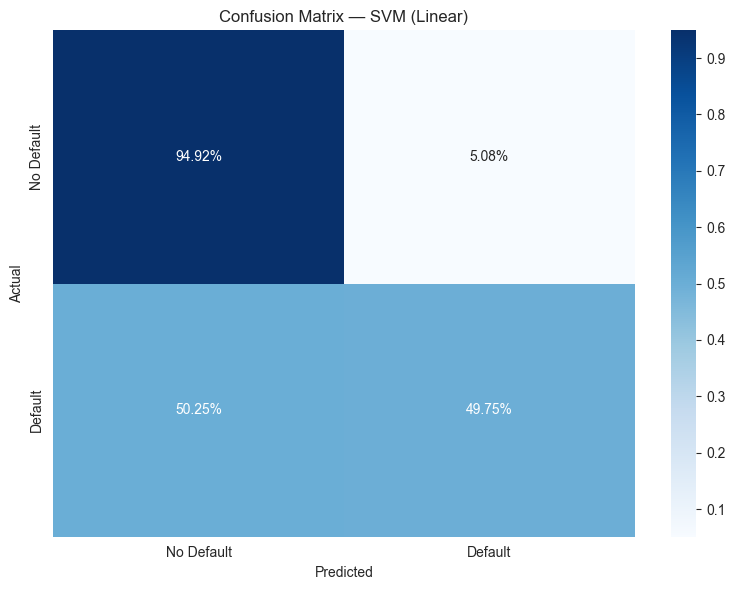

  Saved: models/svm_linear.pkl


In [5]:
print('Training Linear SVM + Platt calibration...')
t0 = time.time()

base_svm = LinearSVC(
    C=1.0,
    class_weight='balanced',
    max_iter=2000,
    random_state=42
)
svm = CalibratedClassifierCV(base_svm, cv=5)
svm.fit(X_train, y_train)
print(f'  Training time: {time.time() - t0:.1f}s')

evaluate_and_store('SVM (Linear)', svm, X_test, y_test)
plot_confusion('SVM (Linear)', svm, X_test, y_test)

joblib.dump(svm, f'{MODELS_DIR}/svm_linear.pkl')
print('  Saved: models/svm_linear.pkl')

## 5. Random Forest

300 decision trees with balanced class weights and `min_samples_leaf=2` to reduce overfitting. `n_jobs=-1` uses all CPU cores.

Training Random Forest...


  Training time: 2.6s


  CV ROC-AUC (5-fold): 0.9325 +/- 0.0053



  Random Forest
  ROC-AUC    : 0.9314
  F1 (macro) : 0.8860
  Accuracy   : 0.9302
  Precision  : 0.9644  (default class)
  Recall     : 0.7058  (default class)
              precision    recall  f1-score   support

  No Default       0.92      0.99      0.96      5094
     Default       0.96      0.71      0.82      1421

    accuracy                           0.93      6515
   macro avg       0.94      0.85      0.89      6515
weighted avg       0.93      0.93      0.93      6515



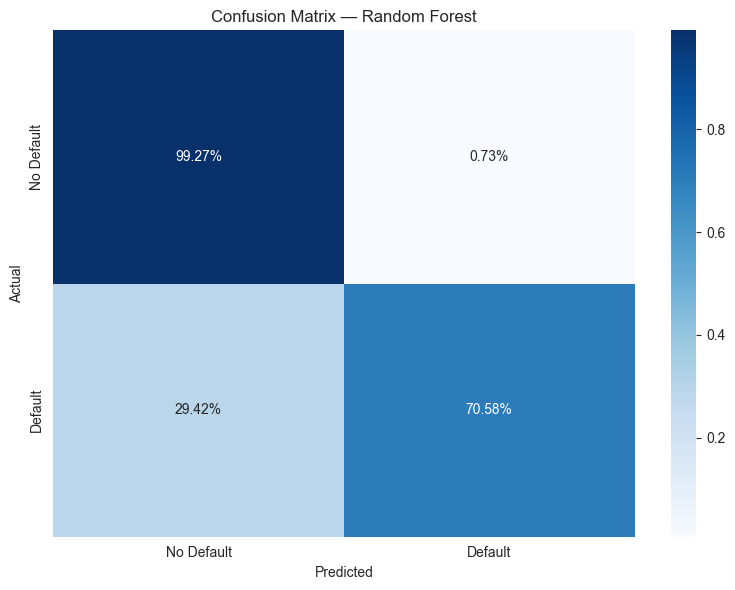

  Saved: models/random_forest.pkl


In [6]:
print('Training Random Forest...')
t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print(f'  Training time: {time.time() - t0:.1f}s')

cv_auc(rf, X_train, y_train)
evaluate_and_store('Random Forest', rf, X_test, y_test)
plot_confusion('Random Forest', rf, X_test, y_test)

joblib.dump(rf, f'{MODELS_DIR}/random_forest.pkl')
print('  Saved: models/random_forest.pkl')

## 6. XGBoost

`scale_pos_weight = n_negative / n_positive` is the recommended way to handle class imbalance in XGBoost. Light subsampling (`subsample=0.8`, `colsample_bytree=0.8`) reduces variance.

scale_pos_weight = 20373 / 5686 = 3.58
Training XGBoost...


  Training time: 0.9s


  CV ROC-AUC (5-fold): 0.9482 +/- 0.0048

  XGBoost
  ROC-AUC    : 0.9469
  F1 (macro) : 0.8804
  Accuracy   : 0.9206
  Precision  : 0.8435  (default class)
  Recall     : 0.7811  (default class)
              precision    recall  f1-score   support

  No Default       0.94      0.96      0.95      5094
     Default       0.84      0.78      0.81      1421

    accuracy                           0.92      6515
   macro avg       0.89      0.87      0.88      6515
weighted avg       0.92      0.92      0.92      6515



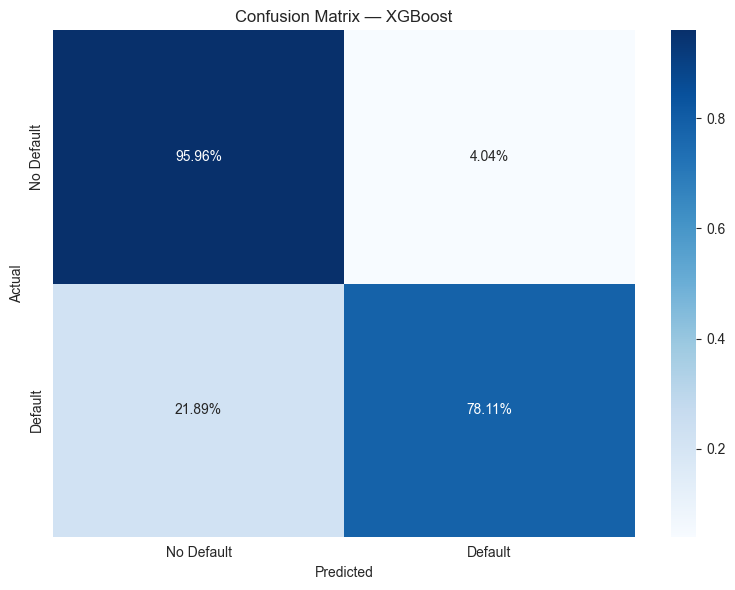

  Saved: models/xgboost.pkl


In [7]:
neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
spw = round(neg / pos, 2)
print(f'scale_pos_weight = {neg} / {pos} = {spw}')

print('Training XGBoost...')
t0 = time.time()

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)
xgb.fit(X_train, y_train)
print(f'  Training time: {time.time() - t0:.1f}s')

cv_auc(xgb, X_train, y_train)
evaluate_and_store('XGBoost', xgb, X_test, y_test)
plot_confusion('XGBoost', xgb, X_test, y_test)

joblib.dump(xgb, f'{MODELS_DIR}/xgboost.pkl')
print('  Saved: models/xgboost.pkl')

## 7. LightGBM

Leaf-wise tree growth (`num_leaves=63`) typically achieves higher accuracy than depth-wise growth. `verbose=-1` suppresses LightGBM's training log.

Training LightGBM...


  Training time: 0.9s


  CV ROC-AUC (5-fold): 0.9470 +/- 0.0056

  LightGBM
  ROC-AUC    : 0.9483
  F1 (macro) : 0.8857
  Accuracy   : 0.9254
  Precision  : 0.8725  (default class)
  Recall     : 0.7706  (default class)
              precision    recall  f1-score   support

  No Default       0.94      0.97      0.95      5094
     Default       0.87      0.77      0.82      1421

    accuracy                           0.93      6515
   macro avg       0.91      0.87      0.89      6515
weighted avg       0.92      0.93      0.92      6515



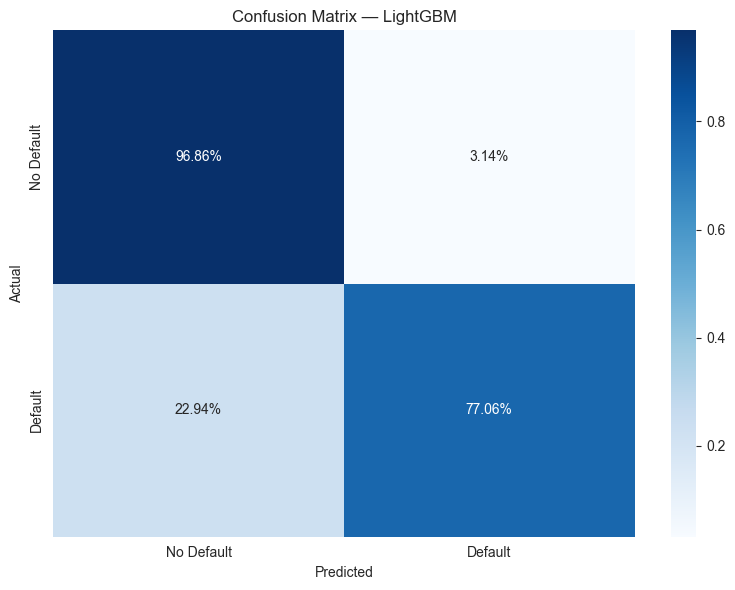

  Saved: models/lightgbm.pkl


In [8]:
print('Training LightGBM...')
t0 = time.time()

lgbm = LGBMClassifier(
    n_estimators=300,
    max_depth=-1,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm.fit(X_train, y_train)
print(f'  Training time: {time.time() - t0:.1f}s')

cv_auc(lgbm, X_train, y_train)
evaluate_and_store('LightGBM', lgbm, X_test, y_test)
plot_confusion('LightGBM', lgbm, X_test, y_test)

joblib.dump(lgbm, f'{MODELS_DIR}/lightgbm.pkl')
print('  Saved: models/lightgbm.pkl')

## 8. Model Comparison

All five models are compared side-by-side. ROC curves are overlaid on a single plot for easy visual comparison.

Model Comparison (sorted by ROC-AUC):
                     ROC-AUC  F1-macro  Accuracy  Precision(1)  Recall(1)
LightGBM              0.9483    0.8857    0.9254        0.8725     0.7706
XGBoost               0.9469    0.8804    0.9206        0.8435     0.7811
Random Forest         0.9314    0.8860    0.9302        0.9644     0.7058
Logistic Regression   0.8595    0.7340    0.7897        0.5121     0.7614
SVM (Linear)          0.8595    0.7505    0.8507        0.7319     0.4975


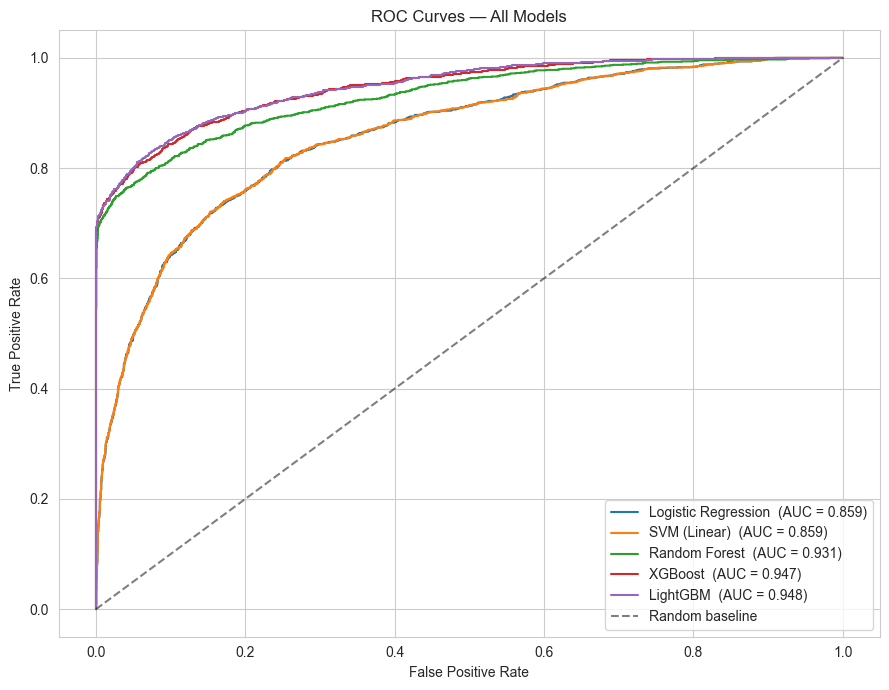

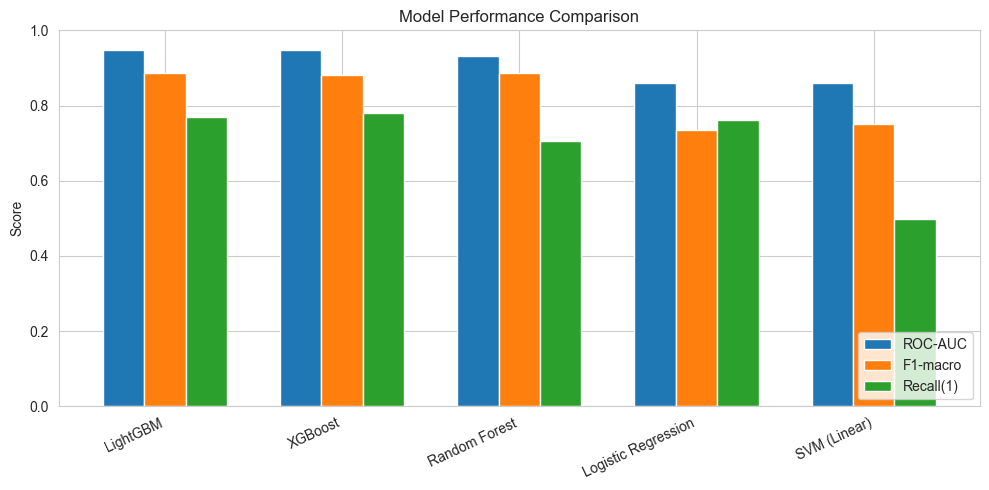

In [9]:
# Summary table
df_results = pd.DataFrame(results).T.sort_values('ROC-AUC', ascending=False)
print('Model Comparison (sorted by ROC-AUC):')
print(df_results.to_string())

# ROC curves
plt.figure(figsize=(9, 7))
for name, y_prob in probs.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name}  (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Bar chart — key metrics
df_results[['ROC-AUC', 'F1-macro', 'Recall(1)']].plot(
    kind='bar', figsize=(10, 5), width=0.7
)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=25, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 9. Save Results

The comparison table is written to `data/processed/model_results.csv` so the evaluation notebook can load it directly.

In [10]:
df_results.to_csv('../data/processed/model_results.csv')
print('Results saved to data/processed/model_results.csv')

print('\nSaved models:')
for fname in sorted(os.listdir(MODELS_DIR)):
    fpath = os.path.join(MODELS_DIR, fname)
    size_kb = os.path.getsize(fpath) / 1024
    print(f'  {fname:<35} {size_kb:>7.0f} KB')

Results saved to data/processed/model_results.csv

Saved models:
  lightgbm.pkl                           2016 KB
  logistic_regression.pkl                   2 KB
  random_forest.pkl                     90038 KB
  svm_linear.pkl                           10 KB
  xgboost.pkl                            1012 KB
